**General Description**

The following notebook contains the code to create, train, validate, and test a rainfall-runoff model using the LSTM-MDN network architecture. The notebook support running experiments in different large-sample hydrology datasets including: CAMELS-GB, CAMELS-US, CAMELS-DE. The details for each dataset can be read from a .yml file.

***Authors:***
- Manuel Alvarez Chaves (manuel.alvarez-chaves@uwaterloo.c)
- Eduardo Acuña Espinoza (eduardo.espinoza@kit.edu)

In [1]:
import datetime
import random
import shutil
import time
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr
# from zarr.errors import ZarrRuntimeWarning

sys.path.append("../src/")
from hy2dl.datasetzoo import get_dataset
from hy2dl.evaluation import calculate_metrics, get_tester
from hy2dl.modelzoo import get_model
from hy2dl.training.basetrainer import BaseTrainer
from hy2dl.utils import get_distribution
from hy2dl.utils.config import Config

base_dir = Path.cwd().resolve()
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

/home/ka/ka_iwu/ka_si3685/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Part 1. Initialize information

In [2]:
# Path to .yml file where the experiment settings are stored.
path_experiment_settings = "../examples/configs/camels_ch_mdn_cmal.yml"

# Read experiment settings
config = Config(path_experiment_settings, base_dir=base_dir)
config.init_experiment()
config.dump()

Dataset = get_dataset(config)
Tester = get_tester(config)

Folder '/pfs/data6/home/ka/ka_iwu/ka_si3685/Hy2DL_eduardo/Hy2DL_new/results/MDN_CMAL_CH_seed_547341' was created to store the results.


Part 2. Create datasets and dataloaders used to train/validate the model

In [3]:
# Basins in CAMELS-US dataset with errors in heading. These must be corrected before loading the data.
# 02108000_lump_maurer_forcing_leap
# 05120500_lump_maurer_forcing_leap
# 09492400_lump_maurer_forcing_leap

In [4]:
# Create training dataset
training_dataset = Dataset(cfg=config, time_period="training")
training_dataset.setup_dataset()
# Initialize training object
trainer = BaseTrainer(cfg=config, training_dataset=training_dataset)

2026-06-04 15:35:00 - Creating training dataset in memory...


Processing gauges: 100%|##########| 196/196 [00:04<00:00, 47.51entity/s] 


2026-06-04 15:35:10 - Dataset created successfully.
2026-06-04 15:35:10 - Validating samples...


Validating samples: 100%|##########| 5685/5685 [00:01<00:00, 4295.19tasks/s]


2026-06-04 15:35:12 - Number of gauges with valid samples: 181
2026-06-04 15:35:12 - Gauges without valid samples in period of interest: 2041, 2113, 2116, 2217, 2392, 2462, 2467, 2615, 2620, 2623, 2629, 2630, 2631, 2640, 2644
2026-06-04 15:35:13 - Number of valid samples: 844 243
2026-06-04 15:35:13 - Mapping ids, dates and features to their corresponding indexes
2026-06-04 15:35:14 - Dataset was successfully standardized.
2026-06-04 15:35:14 - Static attributes were successfully standardized.
2026-06-04 15:35:14 - Time required to process the dataset: 0:00:14
2026-06-04 15:35:28 - ----------------Details training dataloader-----------------
2026-06-04 15:35:28 - Batch structure (number of batches: 3297)
2026-06-04 15:35:28 -              Key              |            Shape             
2026-06-04 15:35:28 - x_d
2026-06-04 15:35:28 -      precipitation(mm/d)      |    torch.Size([256, 365])    
2026-06-04 15:35:28 -     temperature_min(degC)     |    torch.Size([256, 365])    
2026-06-

In [5]:
validation_dataset = Dataset(cfg=config, time_period="validation")
validation_dataset.setup_dataset(check_nan=False, path_scaler = config.path_save_folder / "scaler.yml" )
tester_validation = Tester(cfg=config, evaluation_dataset=validation_dataset)

2026-06-04 15:35:28 - Creating validation dataset in memory...


Processing gauges: 100%|##########| 196/196 [00:03<00:00, 49.88entity/s] 
2026-06-04 15:35:33,657 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/distributed/utils_comm.py", line 416, in

2026-06-04 15:35:34 - Dataset created successfully.
2026-06-04 15:35:34 - Validating samples...


Validating samples: 100%|##########| 1569/1569 [00:00<00:00, 11293.14tasks/s]


2026-06-04 15:35:34 - Number of gauges with valid samples: 196
2026-06-04 15:35:34 - Number of valid samples: 358 092
2026-06-04 15:35:34 - Mapping ids, dates and features to their corresponding indexes
2026-06-04 15:35:35 - Dataset was successfully standardized.
2026-06-04 15:35:35 - Static attributes were successfully standardized.
2026-06-04 15:35:35 - Time required to process the dataset: 0:00:06


Part 3. Train model

In [6]:
# Training report structure
validation_headers = "".join([f"{m:^10}|" for m in config.validation_metric])
config.logger.info("Training model".center(60, "-"))
config.logger.info(f"{'':^16}|{'Training':^21}|{'Validation':^{(11 * len(config.validation_metric)) + 10}}|")
config.logger.info(f"{'Epoch':^5}|{'LR':^10}|{'Loss':^10}|{'Time':^10}|{validation_headers}{'Time':^10}|")

# Loop through epochs
total_time = time.time()
for epoch in range(1, config.epochs + 1):
    trainer.train_model(epoch=epoch)  # Training
    tester_validation.validate_model(model=trainer.model, epoch=epoch)  # Validation
    config.logger.info(trainer.report + tester_validation.validation_report)  # report

config.logger.info(f"Total training time: {datetime.timedelta(seconds=int(time.time() - total_time))}\n")
shutil.rmtree(tester_validation.path_zarr, ignore_errors=True)  # delete validation results

2026-06-04 15:35:35 - -----------------------Training model-----------------------
2026-06-04 15:35:35 -                 |      Training       |           Validation           |
2026-06-04 15:35:35 - Epoch|    LR    |   Loss   |   Time   |   nse    |   nll    |   Time   |


/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


2026-06-04 15:37:29 -   1  | 0.00050  |  0.052   | 0:01:31  |  0.790   |  1.024   | 0:00:22  |


/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


2026-06-04 15:39:20 -   2  | 0.00050  |  -0.175  | 0:01:27  |  0.828   |  0.918   | 0:00:22  |


...

/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


2026-06-04 15:52:18 -   9  | 0.00050  |  -0.342  | 0:01:27  |  0.864   |  0.867   | 0:00:22  |


/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


2026-06-04 15:54:09 -  10  | 0.00050  |  -0.351  | 0:01:28  |  0.861   |  0.876   | 0:00:22  |


KeyboardInterrupt: 

Part 4. Test model

In [7]:
# If I already trained a model, I can re-construct it using the saved parameters from a given epoch
model = get_model(config).to(config.device)
model.load_state_dict(torch.load(config.path_save_folder / "model" / f"model_epoch_10", map_location=config.device))

<All keys matched successfully>

In [8]:
testing_dataset = Dataset(cfg=config, time_period="testing")
testing_dataset.setup_dataset(check_nan=False, path_scaler = config.path_save_folder / "scaler.yml" )
tester_testing = Tester(cfg=config, evaluation_dataset=testing_dataset)

config.logger.info("Testing model...")
testing_time = time.time()
tester_testing.evaluate_model(model = trainer.model)
config.logger.info("Testing completed.")
config.logger.info(f"Total testing time: {datetime.timedelta(seconds=int(time.time() - testing_time))}\n")

2026-06-04 15:55:08 - Creating testing dataset in memory...


Processing gauges: 100%|##########| 196/196 [00:38<00:00,  5.07entity/s]


2026-06-04 15:55:57 - Dataset created successfully.
2026-06-04 15:55:57 - Validating samples...


Validating samples: 100%|##########| 1569/1569 [00:00<00:00, 10807.97tasks/s]


2026-06-04 15:55:57 - Number of gauges with valid samples: 196
2026-06-04 15:55:59 - Number of valid samples: 1 431 780
2026-06-04 15:55:59 - Mapping ids, dates and features to their corresponding indexes
2026-06-04 15:56:00 - Dataset was successfully standardized.
2026-06-04 15:56:00 - Static attributes were successfully standardized.
2026-06-04 15:56:00 - Time required to process the dataset: 0:00:52
2026-06-04 15:56:01 - Testing model...


2026-06-04 15:56:42 - Testing completed.
2026-06-04 15:56:42 - Total testing time: 0:00:40



Part 5. Initial analysis

In [14]:
test_results = xr.open_zarr(tester_testing.path_zarr)
testing_metrics = calculate_metrics(
    ds_results=test_results, metric_name = config.testing_metrics, distribution=config.distribution
)
testing_metrics.to_zarr(config.path_save_folder / "testing_metrics.zarr", mode="w")

/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/ka/ka_iwu/ka_si3685/miniconda3/envs/sb_working_311/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


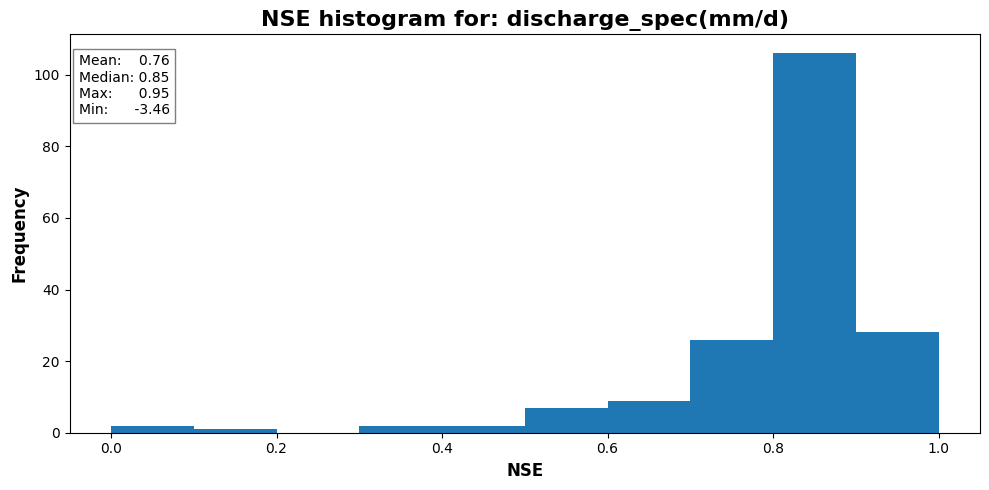

In [15]:
# Loss testing
target_of_interest = random.sample(list(testing_metrics.feature.values), 1)[0]
test_metric = testing_metrics.sel(feature=target_of_interest, metric="nse").round(3).T.to_pandas().dropna()
# Plot the histogram
plt.figure(figsize=(10, 5))
plt.hist(test_metric, bins = np.linspace(0.0, 1.0, 11).tolist())
# Add NSE statistics to the plot
plt.text(
    0.01,
    0.8,
    (
        f"Mean: {'%.2f' % test_metric.mean():>7}\n"
        f"Median: {'%.2f' % test_metric.median():>0}\n"
        f"Max: {'%.2f' % test_metric.max():>9}\n"
        f"Min: {'%.2f' % test_metric.min():>10}"
    ),
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white", alpha=0.5),
)

# Format plot
plt.xlabel("NSE", fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")
plt.title(f"NSE histogram for: {target_of_interest}", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

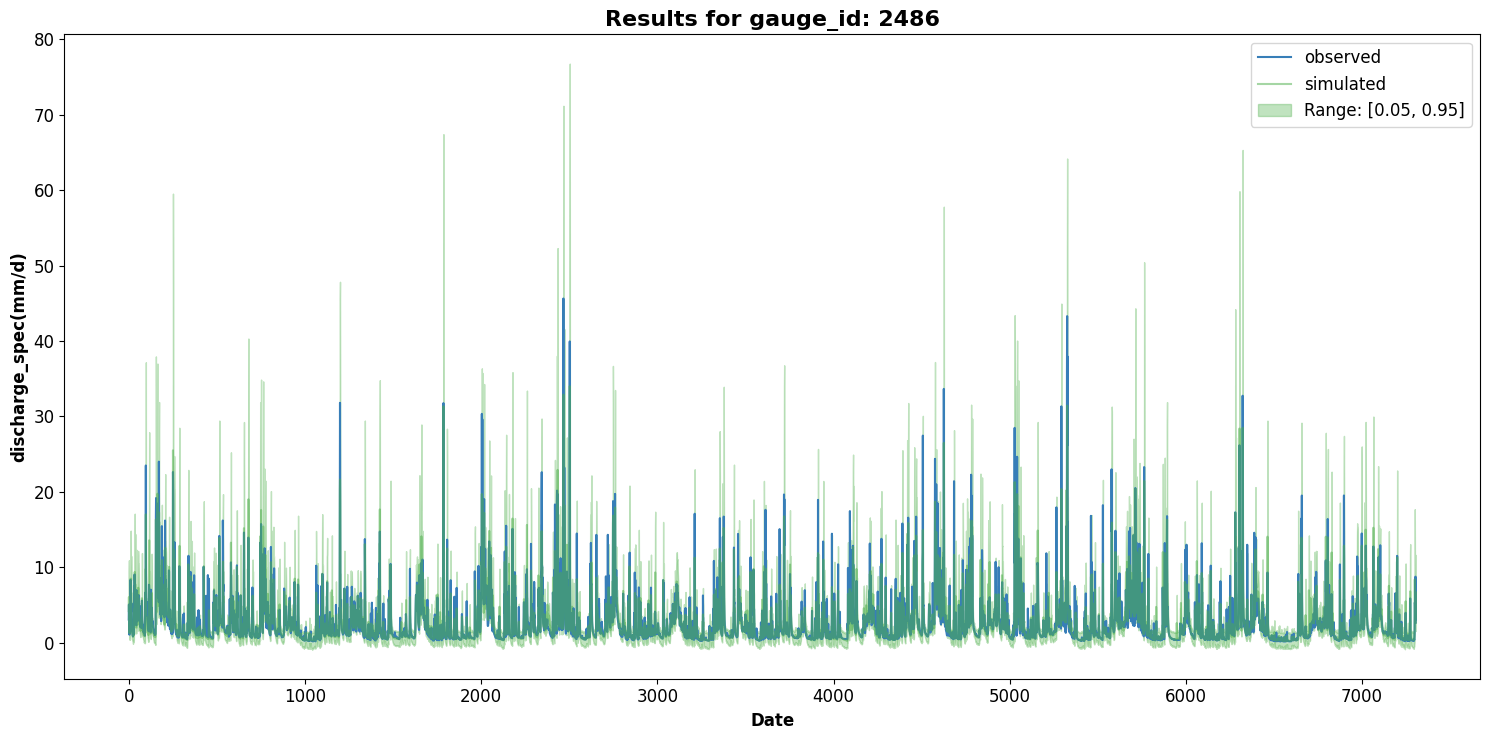

In [16]:
# Plot simulated and observed discharges
basin_to_analyze = random.sample(list(test_results.gauge_id.values), 1)[0]
y_sim = test_results.sel(gauge_id=basin_to_analyze, feature=target_of_interest)["y_sim"].compute().values
y_obs = test_results.sel(gauge_id=basin_to_analyze, feature=target_of_interest)["y_obs"].compute().values

# Calculate quantiles
quantiles = [0.05, 0.95]
distribution = get_distribution(config.distribution)
params = (
    test_results[list(distribution.parameters)]
    .sel(gauge_id=basin_to_analyze, feature=target_of_interest)
    .drop_vars(["gauge_id", "feature"])
)
params = {
    var: torch.tensor(params[var].values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1) for var in params.data_vars
}
weights = (
    torch.tensor(
        test_results["mdn_weight"].sel(gauge_id=basin_to_analyze, feature=target_of_interest).values,
        dtype=torch.float32,
    )
    .unsqueeze(0)
    .unsqueeze(-1)
)
samples = distribution.sample(params=params, weights=weights, num_samples=1000).squeeze(0).squeeze(-1)

plt.figure(figsize=(15, 7.5))
plt.plot(y_obs, label="observed", color=color_palette["observed"])
plt.plot(y_sim, label="simulated", alpha=0.5, color=color_palette["simulated"])
# Prediction from samples

plt.fill_between(
    range(len(y_obs)),
    torch.quantile(samples, q=torch.tensor([0.05, 0.95]), dim=1)[0, :],
    torch.quantile(samples, q=torch.tensor([0.05, 0.95]), dim=1)[1, :],
    color=color_palette["simulated"],
    alpha=0.35,
    label=f"Range: [{quantiles[0]}, {quantiles[-1]}]",
)

# Format plot
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel(target_of_interest, fontsize=12, fontweight="bold")
plt.title(f"Results for gauge_id: {basin_to_analyze}", fontsize=16, fontweight="bold")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend(loc="upper right", fontsize=12)
plt.tight_layout()
plt.show()

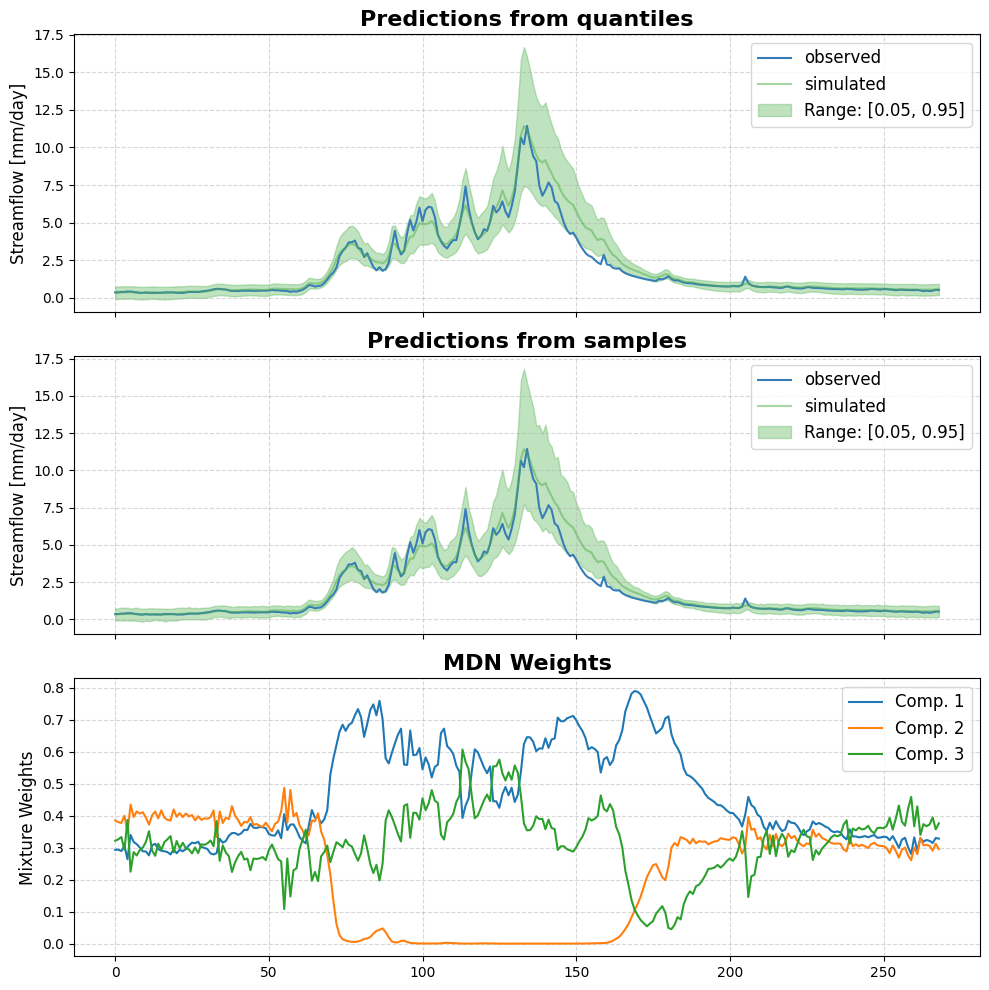

In [37]:
# Subset of results
results_subset = test_results.sel(gauge_id="13011900", feature="QObs(mm/d)", date=slice("1998-02-20", "1998-11-15"))

# Extract simulated and observed values
y_sim = results_subset["y_sim"].compute().values
y_obs = results_subset["y_obs"].compute().values

# Calculate quantiles
distribution = get_distribution(config.distribution)
params = results_subset[list(distribution.parameters)].drop_vars(["gauge_id", "feature"])
params = {
    var: torch.tensor(params[var].values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1) for var in params.data_vars
}
weights = torch.tensor(results_subset["mdn_weight"].values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
quantile = distribution.quantile(params=params, weights=weights, q=quantiles).squeeze(0).squeeze(-1)
samples = distribution.sample(params=params, weights=weights, num_samples=1000).squeeze(0).squeeze(-1)

fig, axes = plt.subplots(nrows=3, figsize=(10, 10), sharex=True)

# Prediction from quantiles
axes[0].plot(y_obs, label="observed", color=color_palette["observed"])
axes[0].plot(y_sim, label="simulated", alpha=0.5, color=color_palette["simulated"])
axes[0].fill_between(
    range(len(y_obs)),
    quantile[:, 0],
    quantile[:, 1],
    color=color_palette["simulated"],
    alpha=0.35,
    label=f"Range: [{quantiles[0]}, {quantiles[-1]}]",
)
axes[0].set_ylabel("Streamflow [mm/day]", fontsize=12)
axes[0].set_title("Predictions from quantiles", fontsize=16, fontweight="bold")
axes[0].grid(ls="--", alpha=0.5)
axes[0].legend(loc="upper right", fontsize=12)

# Prediction from samples
axes[1].plot(y_obs, label="observed", color=color_palette["observed"])
axes[1].plot(y_sim, label="simulated", alpha=0.5, color=color_palette["simulated"])
axes[1].fill_between(
    range(len(y_obs)),
    torch.quantile(samples, q=torch.tensor([0.05, 0.95]), dim=1)[0, :],
    torch.quantile(samples, q=torch.tensor([0.05, 0.95]), dim=1)[1, :],
    color=color_palette["simulated"],
    alpha=0.35,
    label=f"Range: [{quantiles[0]}, {quantiles[-1]}]",
)
axes[1].set_ylabel("Streamflow [mm/day]", fontsize=12)
axes[1].set_title("Predictions from samples", fontsize=16, fontweight="bold")
axes[1].grid(ls="--", alpha=0.5)
axes[1].legend(loc="upper right", fontsize=12)

# MDN weights
for i in range(weights.shape[2]):
    axes[2].plot(weights[0, :, i, 0], label=f"Comp. {i + 1}")

axes[2].set_ylabel("Mixture Weights", fontsize=12)
axes[2].grid(ls="--", alpha=0.5)
axes[2].set_title("MDN Weights", fontsize=16, fontweight="bold")
axes[2].legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
# Calculate PIT values
bins = torch.tensor([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 
                     0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
# CMAL
distribution = get_distribution("laplacian")
results_drn = xr.open_zarr('../results/MDN_CMAL_CH_seed_547341/testing_results.zarr')
params = {}
for var in list(distribution.parameters):
    params[var] = torch.tensor(results_drn[var].values)
weights = torch.tensor(results_drn["mdn_weight"].values)
y_obs = torch.tensor(results_drn["y_obs"].values)
with torch.no_grad():
    pit_values_drn = distribution.pit(params=params, weights=weights, x=y_obs, bins=bins)[0].numpy()

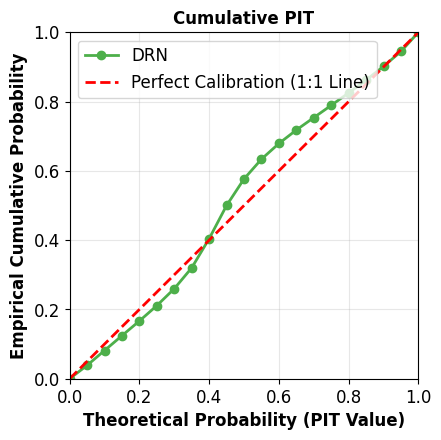

In [22]:
# model's empirical cumulative PIT
color_palette = {"LSTM": "#4daf4a", "benchmark": "#377eb8", "MTS": "#ff7f00", "sMTS": "#984ea3"}
fig, axs = plt.subplots(figsize=(4.5, 4.5))
axs.plot(bins, pit_values_drn, marker="o", color=color_palette["LSTM"], linewidth=2, label="DRN")
axs.plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfect Calibration (1:1 Line)")

# Formatting
axs.set_xlim(0, 1)
axs.set_ylim(0, 1)
axs.set_xlabel("Theoretical Probability (PIT Value)", fontsize=12, fontweight="bold")
axs.set_ylabel("Empirical Cumulative Probability", fontsize=12, fontweight="bold")
axs.tick_params(axis="both", labelsize=12)
axs.grid(alpha=0.3)
axs.legend(loc="upper left", fontsize=12)
axs.set_title("Cumulative PIT", fontsize=12, fontweight="bold")

# fig.suptitle("Benchmark(Klotz2022): CAMELS-US, MDN", fontsize=18, fontweight="bold")
# plt.savefig("Benchmark_Klotz2022.png", bbox_inches="tight", pad_inches=0.1, dpi=300)
plt.show()